# Charting Boulder: Who Balanced the Budget?
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)  
June 2026

Released under a [MIT License](https://opensource.org/licenses/MIT).

---

This notebook analyzes responses to the **Balance Boulder's Budget** interactive published with the *Charting Boulder* column. Readers move sliders to close the city's General Fund gap and may answer an optional demographic survey adapted from the city's 2025 [Boulder Valley Comprehensive Plan (BVCP) survey](https://bouldervalleycompplan.net/). The interactive stores each submission — every slider position plus the survey answers — on Boulder Reporting Lab's own server (see the project's `ARCHITECTURE.md`).

The analysis has four jobs, in order:

1. **Describe** who responded and how they closed the gap (counts, ranges, top-line patterns).
2. **Cross-tabulate** budget choices against demographics, looking for differences worth a sentence in the column.
3. **Compare** the respondent pool to a statistically valid picture of Boulder, using the BVCP survey and the Census ACS as benchmarks.
4. **Reweight** the pool toward those benchmarks to *illustrate* what difference the demographic skew makes — while being explicit about what reweighting can and cannot fix.

> **The honesty spine of this notebook.** The respondents are a **self-selected** pool, not a probability sample. Reweighting can correct for *observed* demographic skew (too few renters, too many older homeowners, and so on). It **cannot** correct for *unobserved* selection bias — the people who choose to balance a city budget online differ from those who don't in ways no weight can capture. Every weighted number below is **illustrative, not an estimate of what Boulder thinks.**


### Libraries

This notebook uses only standard scientific-Python packages (pandas, numpy, scipy, matplotlib, seaborn). No API keys are required. The reweighting section implements raking (iterative proportional fitting) directly, so there is no specialized survey package to install.

Set `STUB_MODE = True` (the default) to run end-to-end on a synthetic, deliberately skewed sample so the notebook executes before real responses exist. Set it to `False` and point `RESPONSES_CSV` at the export from the WordPress table (`wp db export` → one row per submission) to run on live data. The schema both paths produce is identical, so nothing downstream changes.

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats

pd.options.display.max_columns = 100

%matplotlib inline
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Reproducibility: every cell that uses randomness draws from this seed.
RNG_SEED = 2026
rng = np.random.default_rng(RNG_SEED)

# --- Run configuration -------------------------------------------------------
STUB_MODE = True                      # True = synthetic sample; False = live export
RESPONSES_CSV = 'responses.csv'       # path to the WordPress export when STUB_MODE = False
N_STUB = 800                          # size of the synthetic pool


## 1. Load the survey responses

### The data schema

Each submission is one flat row: the General Fund department sliders (`gf_*`), the locked-fund sliders including the capital budget (`fund_*`), the revenue sliders and reserves (`rev_*`, `reserves`), a few derived totals, and one column per survey item (`demo_*`). Slider columns are percent changes in the range −25..25; `0` means the reader left that slider alone. The column names match the database schema in the project's `ARCHITECTURE.md` one-to-one. The survey items are adapted from the city's 2025 [BVCP survey](https://bouldervalleycompplan.net/); several match its wording exactly (years in the valley, tenure, race, gender), while income, age, education, and disability were customized for this interactive and are **not** one-to-one comparable to the BVCP instrument.

In [2]:
# Canonical column lists — keep these in lockstep with the widget's data tables.
GF_SLIDERS = ['gf_police', 'gf_genadmin', 'gf_fire', 'gf_hhs', 'gf_it', 'gf_manager',
              'gf_facilities', 'gf_finance', 'gf_parksrec', 'gf_attorney', 'gf_other']
FUND_SLIDERS = ['fund_capital', 'fund_water', 'fund_openspace', 'fund_transpo',
                'fund_wastewater', 'fund_internal', 'fund_stormwater', 'fund_parkstax',
                'fund_ahf', 'fund_recact', 'fund_climate', 'fund_pds', 'fund_ssb',
                'fund_ccrs', 'fund_arts', 'fund_evict', 'fund_airport']
REV_COLS = ['rev_fees', 'rev_property', 'rev_sales', 'reserves']
DEMO_COLS = ['demo_years', 'demo_area', 'demo_employment', 'demo_commute', 'demo_student',
             'demo_education', 'demo_building', 'demo_tenure', 'demo_income',
             'demo_age', 'demo_race', 'demo_gender', 'demo_lgbtq', 'demo_disability']
SLIDER_COLS = GF_SLIDERS + FUND_SLIDERS

len(SLIDER_COLS), len(REV_COLS), len(DEMO_COLS)

(28, 4, 14)

### Build the analysis frame

In `STUB_MODE` we synthesize a pool that is deliberately skewed the way a self-selected online sample of a college town tends to be — over-represented homeowners, older ages, and high education — so the representativeness and reweighting sections below have something real to correct. The generator is seeded, so the synthetic numbers are stable across runs. When `STUB_MODE = False`, the same columns are read straight from the WordPress export and the synthetic block is skipped entirely.

In [3]:
# The response option lists below mirror the widget's DEMO table exactly so the
# synthetic data and the live export share a vocabulary.
OPTIONS = {
    'demo_years': ['5 years or less', '6-10 years', '11-20 years', 'More than 20 years', 'Prefer not to say'],
    'demo_area': ['North Boulder', 'Central Boulder', 'University Hill', 'South Boulder', 'University of Colorado',
                  'Southeast Boulder', 'East Boulder', 'Crossroads', 'Palo Park', 'Gunbarrel', 'Other',
                  'Outside the city', 'Prefer not to say'],
    'demo_employment': ['Working full time for pay', 'Working part time for pay',
                        'Unemployed, looking for paid work', 'Not retired, not looking for paid work',
                        'Fully retired', 'Prefer not to say'],
    'demo_commute': ['Drive (alone)', 'Carpool or rideshare', 'Bus or other transit', 'Bike or scooter',
                     'Walk or roll', 'Mostly work or stay at home', 'Prefer not to say'],
    'demo_student': ['Yes, an undergraduate student', 'Yes, a graduate student', 'No', 'Prefer not to say'],
    'demo_education': ['No high school diploma', 'High school diploma', 'GED', 'Some college, no degree',
                       'Associate degree', "Bachelor's degree", "Master's degree",
                       'Professional degree (MD, JD, DDS)', 'Doctoral degree (PhD, EdD)', 'Prefer not to say'],
    'demo_building': ['Single-unit house detached from any other houses',
                      'Building with two or more homes (duplex, townhome, apartment or condominium)',
                      'Manufactured home', 'Other', 'Prefer not to say'],
    'demo_tenure': ['Own', 'Rent', 'Other', 'Prefer not to say'],
    'demo_income': ['Less than $25,000 per year', '$25,000 to $49,999 per year', '$50,000 to $99,999 per year',
                    '$100,000 to $149,999 per year', '$150,000 to $299,999 per year', '$300,000 per year or more',
                    'Prefer not to say'],
    'demo_age': ['18-24', '25-34', '35-44', '45-54', '55-64', '65 and over', 'Prefer not to say'],
    'demo_race': ['American Indian or Alaskan Native', 'Asian', 'Black or African American',
                  'Latine/Latinx/Hispanic', 'Middle Eastern or North African',
                  'Native Hawaiian or Pacific Islander', 'White', 'Other', 'Prefer not to say'],
    'demo_gender': ['Woman', 'Man', 'Non-binary/Genderqueer', 'Prefer to self-describe', 'Prefer not to say'],
    'demo_lgbtq': ['Yes', 'No', 'Prefer not to say'],
    'demo_disability': ['Yes, visible', 'Yes, invisible', 'Yes, visible and invisible',
                        'No', 'Prefer not to say'],
}

In [4]:
def _synthesize_pool(n, rng):
    """A deliberately skewed self-selected pool (seeded). For STUB_MODE only."""
    # Skewed marginals: more owners, older, higher-educated than Boulder overall.
    skew = {
        'demo_tenure':    [0.62, 0.30, 0.03, 0.05],                       # Own-heavy
        'demo_age':       [0.06, 0.18, 0.20, 0.20, 0.18, 0.16, 0.02],     # older-skewed
        'demo_education': [0.00, 0.02, 0.01, 0.06, 0.04, 0.34, 0.30, 0.08, 0.13, 0.02],  # degree-heavy
        'demo_income':    [0.06, 0.10, 0.22, 0.22, 0.24, 0.12, 0.04],     # affluent-skewed
        'demo_years':     [0.18, 0.16, 0.24, 0.40, 0.02],
        'demo_gender':    [0.46, 0.46, 0.04, 0.01, 0.03],
        'demo_lgbtq':     [0.14, 0.80, 0.06],
    }
    data = {}
    for col, opts in OPTIONS.items():
        if col in skew:
            p = np.array(skew[col]); p = p / p.sum()
            data[col] = rng.choice(opts, size=n, p=p)
        elif col == 'demo_race':
            # Race is multi-select in the widget; most pick one, a few combine.
            base = ['White', 'Asian', 'Latine/Latinx/Hispanic', 'Black or African American',
                    'Other', 'Prefer not to say']
            wp = np.array([0.74, 0.10, 0.08, 0.02, 0.03, 0.03]); wp = wp / wp.sum()
            picks = rng.choice(base, size=n, p=wp)
            data[col] = picks
        else:
            p = np.ones(len(opts)) / len(opts)
            data[col] = rng.choice(opts, size=n, p=p)
    responses_df = pd.DataFrame(data)

    # Slider behavior, correlated with demographics so cross-tabs are non-trivial:
    # owners lean on cuts; renters and younger readers lean on revenue. Crucially,
    # only SOME readers pull each lever, so the top-line shares have real spread.
    owner = (responses_df['demo_tenure'] == 'Own').to_numpy()
    for col in SLIDER_COLS:
        responses_df[col] = 0
    # Department cuts: owners cut more often and deeper; not everyone cuts.
    def _maybe_cut(prob, lo, hi):
        hits = rng.random(n) < prob
        vals = rng.integers(lo, hi, n)
        return np.where(hits, vals, 0)
    responses_df['gf_police'] = np.where(owner, _maybe_cut(0.70, -20, -2), _maybe_cut(0.45, -12, -1))
    responses_df['gf_genadmin'] = _maybe_cut(0.60, -15, -1)
    responses_df['gf_it'] = _maybe_cut(0.30, -6, 7)
    responses_df['gf_hhs'] = np.where(owner, _maybe_cut(0.35, -8, 5), _maybe_cut(0.30, -2, 12))
    responses_df['gf_parksrec'] = _maybe_cut(0.30, -8, 4)
    # Revenue sources are now percentage-change sliders (−25..25), like the GF
    # departments: a reader can raise, cut, or shift a tax. Most movers raise
    # fees/property; a distinct "shift" cohort trims the regressive sales tax and
    # makes it up on progressive property tax. Reserves stay a one-time $M draw.
    responses_df['rev_fees'] = np.where(owner, _maybe_cut(0.45, -10, 13), _maybe_cut(0.60, -8, 17))
    responses_df['rev_property'] = np.where(owner, _maybe_cut(0.30, -8, 11), _maybe_cut(0.55, -5, 19))
    responses_df['rev_sales'] = np.where(owner, _maybe_cut(0.30, -13, 9), _maybe_cut(0.45, -10, 13))
    shift = rng.random(n) < 0.18                      # the regressive→progressive swap
    responses_df.loc[shift, 'rev_sales'] = rng.integers(-25, -4, shift.sum())
    responses_df.loc[shift, 'rev_property'] = rng.integers(8, 26, shift.sum())
    def _maybe_rev(prob, hi, dec):
        hits = rng.random(n) < prob
        vals = np.round(rng.uniform(0, hi, n), dec)
        return np.where(hits, vals, 0)
    responses_df['reserves'] = _maybe_rev(0.40, 6, 1)
    # Locked sliders: a meaningful minority try to move restricted money (incl. capital).
    responses_df['fund_capital'] = _maybe_cut(0.22, -25, -2)
    responses_df['fund_arts'] = _maybe_cut(0.10, -25, 6)
    responses_df['fund_openspace'] = _maybe_cut(0.12, -20, 6)
    responses_df['scenario'] = rng.choice(['y2026', 'downturn'], size=n, p=[0.8, 0.2])
    responses_df['ts'] = pd.Timestamp('2026-06-01') + pd.to_timedelta(rng.integers(0, 12*24*60, n), unit='m')
    return responses_df

if STUB_MODE:
    responses_df = _synthesize_pool(N_STUB, rng)
    print(f'STUB_MODE: synthesized {len(responses_df):,} responses (seed={RNG_SEED}).')
else:
    responses_df = pd.read_csv(RESPONSES_CSV)
    print(f'Loaded {len(responses_df):,} responses from {RESPONSES_CSV}.')

responses_df.head()

STUB_MODE: synthesized 800 responses (seed=2026).


,demo_years,demo_area,demo_employment,demo_commute,demo_student,demo_education,demo_building,demo_tenure,demo_income,demo_age,demo_race,demo_gender,demo_lgbtq,demo_disability,gf_police,gf_genadmin,gf_fire,gf_hhs,gf_it,gf_manager,gf_facilities,gf_finance,gf_parksrec,gf_attorney,gf_other,fund_capital,fund_water,fund_openspace,fund_transpo,fund_wastewater,fund_internal,fund_stormwater,fund_parkstax,fund_ahf,fund_recact,fund_climate,fund_pds,fund_ssb,fund_ccrs,fund_arts,fund_evict,fund_airport,rev_fees,rev_property,rev_sales,reserves,scenario,ts
0,5 years or less,Other,Fully retired,Bike or scooter,"Yes, an undergraduate student","Doctoral degree (PhD, EdD)","Building with two or more homes (duplex, townh...",Own,"Less than $25,000 per year",45-54,White,Man,No,No,-8,0,0,0,-4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,-12,4.3,y2026,2026-06-12 13:31:00
1,More than 20 years,Gunbarrel,Working full time for pay,Prefer not to say,Prefer not to say,Bachelor's degree,"Building with two or more homes (duplex, townh...",Own,"$50,000 to $99,999 per year",Prefer not to say,White,Woman,No,Prefer not to say,-7,-10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,y2026,2026-06-08 03:54:00
2,11-20 years,Other,Working part time for pay,Carpool or rideshare,No,"Doctoral degree (PhD, EdD)",Manufactured home,Own,"$50,000 to $99,999 per year",35-44,White,Man,Yes,"Yes, invisible",-17,-2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-2,0,0,11,0,0,5.2,y2026,2026-06-05 23:32:00
3,11-20 years,Southeast Boulder,Prefer not to say,Mostly work or stay at home,No,GED,Manufactured home,Rent,"$150,000 to $299,999 per year",65 and over,White,Man,No,No,-12,-14,0,0,0,0,0,0,0,0,0,-10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,-5,-2,0.0,y2026,2026-06-02 16:28:00
4,11-20 years,University Hill,Working full time for pay,Mostly work or stay at home,"Yes, a graduate student","Professional degree (MD, JD, DDS)",Other,Own,"$100,000 to $149,999 per year",45-54,Prefer not to say,Woman,No,"Yes, visible",0,-15,0,3,-5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,downturn,2026-06-06 07:49:00


### Integrity checks

Before any number is reported, confirm the frame is shaped the way the schema promises: the expected columns are present, every slider sits inside its legal −25..25 range, and every retained row answered at least one survey question (the interactive enforces this rule client- and server-side, so a violation here means a bad export, not a real respondent).

In [5]:
# Every schema column is present.
_expected = set(SLIDER_COLS + REV_COLS + DEMO_COLS)
_missing = _expected - set(responses_df.columns)
assert not _missing, f'Missing expected columns: {sorted(_missing)}'

# Sliders are integers within the widget's −25..25 bounds. The revenue sources
# are now percentage-change sliders too (a reader can cut or shift a tax), so
# they share those bounds; only one-time reserves are a non-negative $M draw.
_pct_cols = SLIDER_COLS + ['rev_fees', 'rev_property', 'rev_sales']
for _c in _pct_cols:
    assert responses_df[_c].between(-25, 25).all(), f'{_c} has out-of-range values'

# One-time reserves are a non-negative dollar amount.
assert (responses_df['reserves'] >= 0).all(), 'reserves has negative values'

# Power-of-two truncation watch (an Excel round-trip would betray itself here).
assert len(responses_df) not in (256, 16384, 65536, 1048576), 'Suspicious row count — check for truncation'

# At least one demographic answer per row (the interactive requires it to submit).
_answered = responses_df[DEMO_COLS].notna().sum(axis=1)
assert (_answered >= 1).all(), f'{(_answered < 1).sum()} rows answered no survey questions'

print('Integrity checks passed:', len(responses_df), 'rows,',
      len(_pct_cols), 'sliders,', len(DEMO_COLS), 'survey items.')

Integrity checks passed: 800 rows, 31 sliders, 14 survey items.


## 2. Basic counts and ranges

### How many responses, and how complete?

The first thing a reader of the column will ask is how big the pool is and how much of the optional survey people actually filled in. `n_responses` and the completion figures below are pinned variables — every count the column quotes traces back to one of them.

In [6]:
n_responses = len(responses_df)

# Completion: how many of the 13 survey items each respondent answered.
answers_per_person_s = responses_df[DEMO_COLS].notna().sum(axis=1)
median_answers = int(answers_per_person_s.median())
pct_answered_all = (answers_per_person_s == len(DEMO_COLS)).mean()

print(f'Responses:                 {n_responses:,}')
print(f'Survey items (max):        {len(DEMO_COLS)}')
print(f'Median items answered:     {median_answers}')
print(f'Share answering all items: {pct_answered_all:.1%}')
print(f'Date range:                {responses_df["ts"].min():%Y-%m-%d} to {responses_df["ts"].max():%Y-%m-%d}')


Responses:                 800
Survey items (max):        14
Median items answered:     14
Share answering all items: 100.0%
Date range:                2026-06-01 to 2026-06-12


### Per-item response counts

Item non-response matters for everything downstream: a demographic answered by only a handful of people cannot carry a cross-tab or a weighting cell. This table is the denominator audit for the rest of the notebook.

In [7]:
item_counts_df = pd.DataFrame({
    'answered': responses_df[DEMO_COLS].notna().sum(),
    'answered_pct': responses_df[DEMO_COLS].notna().mean(),
    'prefer_not_pct': (responses_df[DEMO_COLS] == 'Prefer not to say').mean(),
})
item_counts_df['answered_pct'] = item_counts_df['answered_pct'].round(3)
item_counts_df['prefer_not_pct'] = item_counts_df['prefer_not_pct'].round(3)
item_counts_df.sort_values('answered', ascending=False)


,answered,answered_pct,prefer_not_pct
demo_years,800,1.0,0.020
demo_area,800,1.0,0.076
demo_employment,800,1.0,0.172
demo_commute,800,1.0,0.136
demo_student,800,1.0,0.230
demo_education,800,1.0,0.020
demo_building,800,1.0,0.235
demo_tenure,800,1.0,0.055
demo_income,800,1.0,0.028
demo_age,800,1.0,0.026


### Slider ranges

A quick describe() on the slider columns confirms the inputs behaved — bounded at ±25 percent — and shows where readers actually pushed. Columns whose min and max are both near zero are sliders most readers left alone.

In [8]:
slider_summary_df = responses_df[SLIDER_COLS + REV_COLS].describe().T[['mean', 'std', 'min', 'max']].round(2)
slider_summary_df


,mean,std,min,max
gf_police,-6.08,6.44,-20.0,0.0
gf_genadmin,-4.91,5.13,-15.0,0.0
gf_fire,0.00,0.00,0.0,0.0
gf_hhs,-0.04,2.83,-8.0,11.0
gf_it,0.03,1.97,-6.0,6.0
gf_manager,0.00,0.00,0.0,0.0
gf_facilities,0.00,0.00,0.0,0.0
gf_finance,0.00,0.00,0.0,0.0
gf_parksrec,-0.75,2.19,-8.0,3.0
gf_attorney,0.00,0.00,0.0,0.0


## 3. Top-line budget-solving patterns

### Cuts vs. revenue: how did people close the gap?

The interactive lets a reader close the gap three ways: cut General Fund spending, raise revenue (fees the city can set, or taxes that need a public vote), or spend one-time reserves. The split between these is the column's central descriptive finding. We reconstruct each reader's *approach* from their slider positions.

Because the synthetic stub does not attach dollar weights to each department, we summarize cuts as the **mean percentage cut across General Fund sliders** (negative = cut) and revenue as the raw slider settings. On live data, swap in the dollar-weighted figures the widget computes (`spend_change`, `revenue_only`) if they are exported.

In [9]:
# Approach summaries, per respondent.
responses_df['mean_gf_change'] = responses_df[GF_SLIDERS].mean(axis=1)        # negative = net cut
responses_df['any_cut'] = (responses_df[GF_SLIDERS] < 0).any(axis=1)
responses_df['used_vote'] = (responses_df['rev_property'] > 0) | (responses_df['rev_sales'] > 0)
responses_df['used_fees'] = responses_df['rev_fees'] > 0
responses_df['used_reserves'] = responses_df['reserves'] > 0
responses_df['used_revenue'] = responses_df['used_vote'] | responses_df['used_fees']
# A reader "shifts" the mix when they raise one vote-tax while cutting the other —
# e.g. trimming the regressive sales tax and leaning on progressive property tax.
responses_df['shifted_revenue'] = (
    ((responses_df['rev_property'] > 0) & (responses_df['rev_sales'] < 0)) |
    ((responses_df['rev_sales'] > 0) & (responses_df['rev_property'] < 0))
)

topline = {
    'made at least one cut': responses_df['any_cut'].mean(),
    'raised some revenue (fees or taxes)': responses_df['used_revenue'].mean(),
    'used a tax requiring a public vote': responses_df['used_vote'].mean(),
    'shifted the tax mix (sales <-> property)': responses_df['shifted_revenue'].mean(),
    'leaned on one-time reserves': responses_df['used_reserves'].mean(),
}
topline_s = pd.Series(topline).sort_values(ascending=False)
print('Share of respondents who...')
for label, share in topline_s.items():
    print(f'  {share:5.1%}  {label}')

Share of respondents who...
  90.1%  made at least one cut
  62.6%  raised some revenue (fees or taxes)
  47.9%  used a tax requiring a public vote
  39.1%  leaned on one-time reserves
  25.8%  shifted the tax mix (sales <-> property)


### Which departments took the deepest cuts?

Averaging each General Fund slider across all respondents shows where the pool was willing to cut and where it protected spending. Negative bars are average cuts; positive bars are average requested increases.

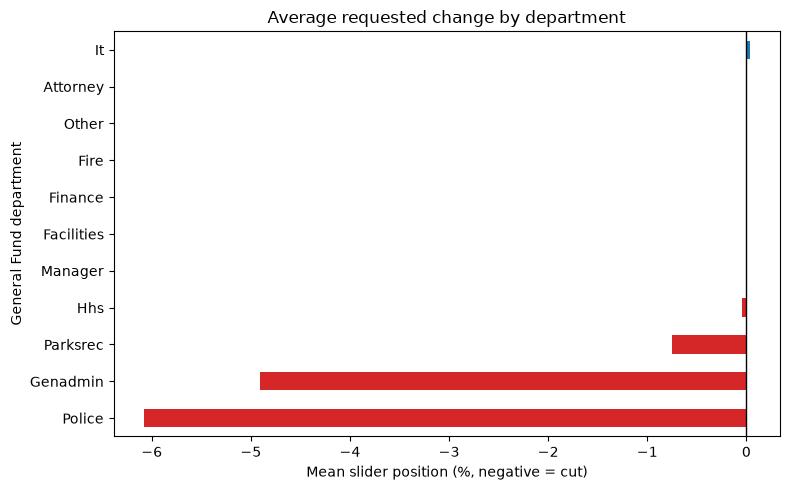

In [10]:
dept_means_s = responses_df[GF_SLIDERS].mean().sort_values()
dept_means_s = dept_means_s.rename(lambda c: c.replace('gf_', '').replace('_', ' ').title())

f, ax = plt.subplots(figsize=(8, 5))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in dept_means_s.values]
dept_means_s.plot.barh(ax=ax, color=colors, lw=3)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean slider position (%, negative = cut)')
ax.set_ylabel('General Fund department')
ax.set_title('Average requested change by department')
plt.tight_layout()


### The locked-fund lesson: did people try to raid restricted money?

The interactive's argument is that most of the budget is ring-fenced. One behavioral check: how often readers moved a *locked* slider (including the capital budget), whose savings can't reach the General Fund. A high rate is itself a finding — it suggests the constraint isn't obvious until the tool shows you.

In [11]:
moved_locked_s = (responses_df[FUND_SLIDERS] != 0).any(axis=1)
pct_moved_locked = moved_locked_s.mean()
pct_moved_capital = (responses_df['fund_capital'] != 0).mean()
print(f'Moved at least one locked fund:  {pct_moved_locked:.1%}')
print(f'Moved the capital budget slider: {pct_moved_capital:.1%}')


Moved at least one locked fund:  42.2%
Moved the capital budget slider: 24.8%


## 4. Exploratory cross-tabs against demographics

### A reusable cross-tab helper

The question throughout this section is whether budget choices differ by who the respondent is. The helper below builds a normalized cross-tab of a budget behavior against a demographic, drops the small 'Prefer not to say' and thin cells that can't support a comparison, and runs a chi-square test of independence as a rough flag for whether a difference is worth a sentence. The chi-square is a screening device, not a population inference — these are self-selected respondents, so a 'significant' result describes this pool, not Boulder.

In [12]:
def crosstab_behavior(df, demo_col, behavior_col, min_cell=10, drop=('Prefer not to say',)):
    """Normalized cross-tab + chi-square screen for one demographic vs. one behavior."""
    c0 = df[demo_col].notna() & ~df[demo_col].isin(drop)
    sub_df = df.loc[c0, [demo_col, behavior_col]].copy()
    # Keep only demographic groups with enough respondents to compare.
    keep = sub_df[demo_col].value_counts()
    keep = keep[keep >= min_cell].index
    sub_df = sub_df[sub_df[demo_col].isin(keep)]
    if sub_df[demo_col].nunique() < 2:
        return None, None, None
    counts = pd.crosstab(sub_df[demo_col], sub_df[behavior_col])
    shares = pd.crosstab(sub_df[demo_col], sub_df[behavior_col], normalize='index').round(3)
    chi2, p, dof, _ = stats.chi2_contingency(counts)
    return shares, counts, p


### Revenue vs. cuts, by housing tenure

The cleanest hypothesis to look at first: do renters and owners close the gap differently? Tenure is also the variable where the respondent pool is most likely to diverge from Boulder, which makes it the natural bridge to the representativeness section.

In [13]:
shares_df, counts_df, p_val = crosstab_behavior(responses_df, 'demo_tenure', 'used_vote')
print(f'Used a tax requiring a public vote, by tenure (chi-square p = {p_val:.3g}):')
shares_df


Used a tax requiring a public vote, by tenure (chi-square p = 5.85e-12):


used_vote,False,True
demo_tenure,,
Other,0.500,0.500
Own,0.628,0.372
Rent,0.343,0.657


### The same view as a chart

A grouped bar of the share of each group choosing each approach makes the pattern legible at a glance. This is a draft chart; the published version would be rebuilt in Datawrapper per the chart-discipline reference.

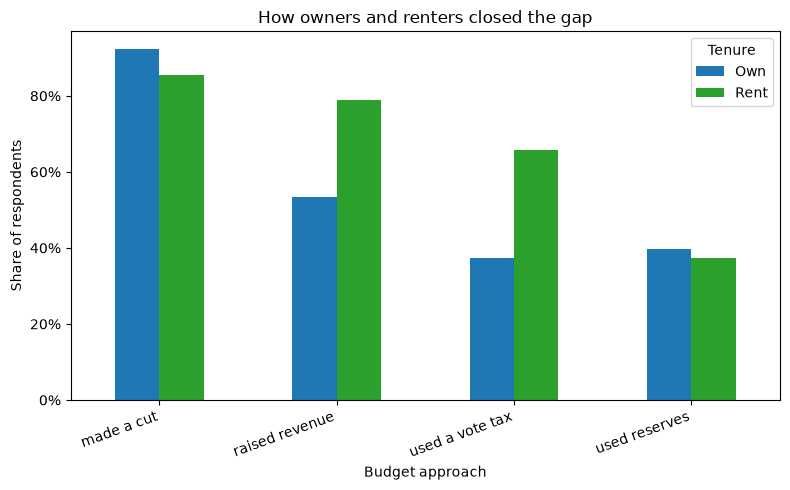

In [14]:
behaviors = ['any_cut', 'used_revenue', 'used_vote', 'used_reserves']
by_tenure_df = (responses_df[responses_df['demo_tenure'].isin(['Own', 'Rent'])]
                .groupby('demo_tenure')[behaviors].mean())

f, ax = plt.subplots(figsize=(8, 5))
by_tenure_df.T.plot.bar(ax=ax, color=['tab:blue', 'tab:green'], lw=3)
ax.set_ylabel('Share of respondents')
ax.set_xlabel('Budget approach')
ax.set_title('How owners and renters closed the gap')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticklabels(['made a cut', 'raised revenue', 'used a vote tax', 'used reserves'], rotation=20, ha='right')
ax.legend(title='Tenure')
plt.tight_layout()


### Scanning several demographics at once

Rather than eyeball every pairing, screen each demographic against each budget behavior with the chi-square helper and collect the p-values into one table. Small values flag pairings worth a closer look (and possibly a sentence in the column); they do **not** establish anything about Boulder at large. Blank cells are pairings without enough respondents to test.

In [15]:
screen_demos = ['demo_tenure', 'demo_age', 'demo_income', 'demo_education',
                'demo_years', 'demo_gender', 'demo_building']
screen_behaviors = ['any_cut', 'used_revenue', 'used_vote', 'used_reserves']

screen = pd.DataFrame(index=screen_demos, columns=screen_behaviors, dtype=float)
for d in screen_demos:
    for b in screen_behaviors:
        _, _, p = crosstab_behavior(responses_df, d, b)
        screen.loc[d, b] = p
screen.round(3)


,any_cut,used_revenue,used_vote,used_reserves
demo_tenure,0.007,0.000,0.000,0.789
demo_age,0.654,0.154,0.256,0.081
demo_income,0.752,0.362,0.686,0.175
demo_education,0.272,0.197,0.327,0.934
demo_years,0.770,0.533,0.304,0.674
demo_gender,0.193,0.682,0.513,0.848
demo_building,0.201,0.547,0.158,0.345


A note on reading this table: with seven demographics times four behaviors we are running 28 screens, so some small p-values will appear by chance alone. Treat the table as a place to *look*, confirm any candidate finding by inspecting the actual shares (as in the tenure example), and report effect sizes — how many points apart the groups are — rather than p-values in the column itself.

## 5. How representative is the pool? Benchmarks from BVCP and the Census

### Two benchmarks, two questions

'Representative of what?' has two answers, and we keep both:

- The **2025 BVCP survey** is the city's own *statistically valid* instrument — a probability-based read of Boulder Valley residents. Comparing to it answers: *does our self-selected pool look like the city's valid survey?*
- The **Census ACS** (2019–2023 5-year estimates for the city of Boulder) is the population benchmark. Comparing to it answers: *does our pool look like Boulder's adult population?*

> **Both benchmark tables below are placeholders pending the exact published figures.** The ACS values are drawn from the 2019–2023 ACS 5-year estimates for the city of Boulder and should be replaced with exact pulls from the relevant ACS tables (tenure **B25003**, age **B01001**, educational attainment **B15003**, household income **B19001**) via the [Census API](https://www.census.gov/data/developers/data-sets/acs-5year.html) or [data.census.gov](https://data.census.gov/). The BVCP column should be filled from the city's published [BVCP survey](https://bouldervalleycompplan.net/) topline. Until then, treat the *gaps* as illustrative of the method, not as final numbers.

In [16]:
# --- Benchmark marginals (shares within each variable) -----------------------
# PLACEHOLDER VALUES. Replace BVCP with the city's published survey topline and ACS
# with exact table pulls (see the markdown note above). ACS figures here approximate
# the 2019-2023 ACS 5-year estimates for the city of Boulder.

# Tenure: ACS B25003 for the city of Boulder is ~48% owner / 52% renter.
benchmarks = {
    'demo_tenure': pd.DataFrame({
        'pool':  np.nan,  # filled from the data below
        'bvcp':  {'Own': 0.52, 'Rent': 0.48},                 # PLACEHOLDER
        'acs':   {'Own': 0.48, 'Rent': 0.52},                 # ~ACS B25003, city of Boulder
    }),
    'demo_age': pd.DataFrame({
        'pool':  np.nan,
        'bvcp':  {'18-24': 0.15, '25-34': 0.20, '35-44': 0.16,
                  '45-54': 0.14, '55-64': 0.15, '65 and over': 0.20},   # PLACEHOLDER
        'acs':   {'18-24': 0.27, '25-34': 0.19, '35-44': 0.13,
                  '45-54': 0.11, '55-64': 0.12, '65 and over': 0.18},   # ~ACS B01001 (18+), city
    }),
    'demo_education': pd.DataFrame({
        'pool':  np.nan,
        'bvcp':  {'High school diploma': 0.05, 'Some college, no degree': 0.10,
                  'Associate degree': 0.04, "Bachelor's degree": 0.34,
                  "Master's degree": 0.28, 'Doctoral degree (PhD, EdD)': 0.12,
                  'Professional degree (MD, JD, DDS)': 0.07},            # PLACEHOLDER
        'acs':   {'High school diploma': 0.09, 'Some college, no degree': 0.12,
                  'Associate degree': 0.03, "Bachelor's degree": 0.40,
                  "Master's degree": 0.24, 'Doctoral degree (PhD, EdD)': 0.06,
                  'Professional degree (MD, JD, DDS)': 0.06},            # ~ACS B15003 (25+), city
    }),
    'demo_income': pd.DataFrame({
        'pool':  np.nan,
        'bvcp':  {'Less than $25,000 per year': 0.12, '$25,000 to $49,999 per year': 0.13,
                  '$50,000 to $99,999 per year': 0.22, '$100,000 to $149,999 per year': 0.20,
                  '$150,000 to $299,999 per year': 0.23, '$300,000 per year or more': 0.10},  # PLACEHOLDER
        'acs':   {'Less than $25,000 per year': 0.18, '$25,000 to $49,999 per year': 0.15,
                  '$50,000 to $99,999 per year': 0.22, '$100,000 to $149,999 per year': 0.17,
                  '$150,000 to $299,999 per year': 0.19, '$300,000 per year or more': 0.09},  # ~ACS B19001, city
    }),
}
list(benchmarks)

['demo_tenure', 'demo_age', 'demo_education', 'demo_income']

### Pool vs. benchmarks, side by side

For each benchmarked variable, compute the pool's own distribution (excluding 'Prefer not to say' so the shares are comparable to the benchmarks) and place it next to the BVCP and ACS columns. The `gap_vs_acs` column is the percentage-point difference between the pool and the population — the thing reweighting will try to close.

In [17]:
def pool_distribution(df, col, categories):
    """Share of each category among respondents who gave a real answer."""
    c0 = df[col].notna() & (df[col] != 'Prefer not to say')
    counts = df.loc[c0, col].value_counts()
    return (counts.reindex(categories).fillna(0) / counts.sum())

rep_tables = {}
for col, bench_df in benchmarks.items():
    cats = [c for c in bench_df.index]
    out = bench_df.copy()
    out['pool'] = pool_distribution(responses_df, col, cats)
    out['gap_vs_acs'] = (out['pool'] - out['acs'])
    out['gap_vs_bvcp'] = (out['pool'] - out['bvcp'])
    rep_tables[col] = out.round(3)

rep_tables['demo_tenure']


,pool,bvcp,acs,gap_vs_acs,gap_vs_bvcp
Own,0.657,0.52,0.48,0.177,0.137
Rent,0.308,0.48,0.52,-0.212,-0.172


### A representativeness chart for one variable

Tenure is the sharpest illustration: a self-selected civic-engagement pool typically over-represents homeowners, who have more at stake in municipal budgets and more time to spend on a budget puzzle. The chart shows the three distributions side by side.

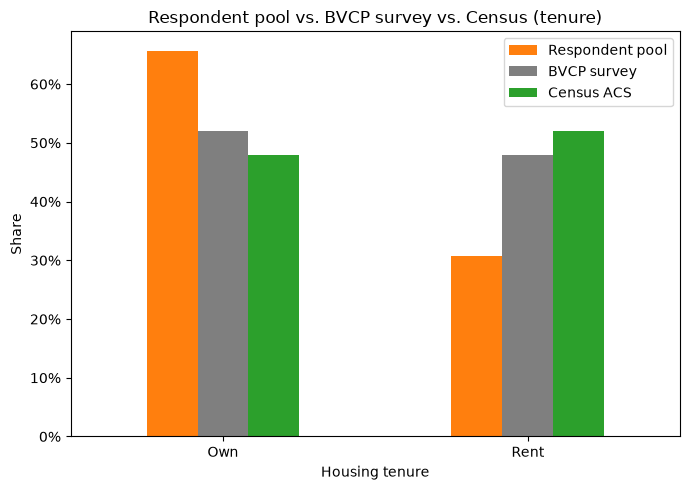

In [18]:
ten_df = rep_tables['demo_tenure'][['pool', 'bvcp', 'acs']]

f, ax = plt.subplots(figsize=(7, 5))
ten_df.plot.bar(ax=ax, color=['tab:orange', 'tab:gray', 'tab:green'], lw=3)
ax.set_ylabel('Share')
ax.set_xlabel('Housing tenure')
ax.set_title('Respondent pool vs. BVCP survey vs. Census (tenure)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(['Respondent pool', 'BVCP survey', 'Census ACS'])
ax.set_xticklabels(ten_df.index, rotation=0)
plt.tight_layout()


## 6. Reweighting: estimating the BRL-pool-vs-Boulder gap

### What reweighting does, and what it can't

If the pool has too many homeowners, one fix is to count each homeowner's response a little less and each renter's a little more, so the *weighted* pool matches Boulder's tenure split. That is **post-stratification**. Extending it to match several variables at once — tenure *and* age *and* income — is **raking**, or iterative proportional fitting (IPF): cycle through the variables, rescaling weights to match one margin at a time, and repeat until the weights stop moving.

Two cautions frame everything in this section:

1. **Reweighting corrects observed skew only.** It makes the pool's *measured* demographics match the target. It does nothing about the unmeasured ways budget-puzzle-takers differ from non-takers (civic interest, free time, strong priors about city spending). A perfectly reweighted self-selected sample is still a self-selected sample.
2. **Weights cost precision.** Up-weighting a small group inflates the variance of any estimate; the *effective sample size* can be far below the row count. We quantify that cost so it isn't hidden.

### Step 1 — post-stratification on a single variable (tenure)

Start with the simplest case to make the mechanic visible. The weight for each respondent is the target share of their group divided by the pool's share of that group. Renters (under-represented) get weights above 1; owners (over-represented) get weights below 1. We weight toward the ACS population benchmark here.

In [19]:
def post_stratify(df, col, target, drop=('Prefer not to say',)):
    """Single-variable post-stratification weights toward `target` (a share dict)."""
    c0 = df[col].notna() & ~df[col].isin(drop)
    pool_share = df.loc[c0, col].value_counts(normalize=True)
    w = pd.Series(1.0, index=df.index)
    for cat, tgt in target.items():
        if cat in pool_share.index and pool_share[cat] > 0:
            w.loc[df[col] == cat] = tgt / pool_share[cat]
    w.loc[~c0] = np.nan      # rows that skipped this item can't be post-stratified on it
    return w

tenure_target = benchmarks['demo_tenure']['acs'].to_dict()
w_tenure_s = post_stratify(responses_df, 'demo_tenure', tenure_target)
print('Tenure post-stratification weights (toward ACS):')
print(w_tenure_s.groupby(responses_df['demo_tenure']).mean().round(3).dropna())


Tenure post-stratification weights (toward ACS):
demo_tenure
Other    1.000
Own      0.730
Rent     1.687
dtype: float64


### What the single weight changes

Recompute one top-line behavior — the share who used a tax requiring a public vote — unweighted and then weighted toward the ACS tenure split. The movement is the tenure-skew correction, in isolation.

In [20]:
def weighted_mean(values_s, weights_s):
    c0 = values_s.notna() & weights_s.notna()
    v, w = values_s[c0].astype(float), weights_s[c0]
    return np.average(v, weights=w)

raw_vote = responses_df['used_vote'].mean()
adj_vote = weighted_mean(responses_df['used_vote'], w_tenure_s)
print(f'Used a vote-tax  | unweighted: {raw_vote:.1%}   tenure-weighted (ACS): {adj_vote:.1%}')


Used a vote-tax  | unweighted: 47.9%   tenure-weighted (ACS): 51.9%


### Step 2 — raking on several variables at once

Real reweighting matches more than one margin. The raking routine below cycles through tenure, age, income, and education, each iteration rescaling the running weight so the weighted pool matches that variable's target, then repeats until the weights converge. Respondents who skipped one of the raking variables keep a neutral factor for that variable (a simple, transparent choice; a production analysis might instead restrict to complete cases or impute). Weights are trimmed at the end to keep any single respondent from dominating.

In [21]:
def rake(df, targets, drop=('Prefer not to say',), max_iter=50, tol=1e-6, trim=(0.2, 5.0)):
    """Iterative proportional fitting toward several marginal `targets`.

    targets: dict of {column: {category: target_share}}.
    Returns a weight Series (mean 1.0) over all rows.
    """
    w = pd.Series(1.0, index=df.index)
    for _ in range(max_iter):
        w_before = w.copy()
        for col, target in targets.items():
            c0 = df[col].notna() & ~df[col].isin(drop)
            # Weighted share currently in each category.
            cur = w[c0].groupby(df.loc[c0, col]).sum()
            cur = cur / cur.sum()
            for cat, tgt in target.items():
                if cat in cur.index and cur[cat] > 0:
                    factor = tgt / cur[cat]
                    w.loc[(df[col] == cat) & c0] *= factor
        # Renormalize to mean 1 and check convergence.
        w *= len(w) / w.sum()
        if (w - w_before).abs().max() < tol:
            break
    # Trim extreme weights, then renormalize once more.
    lo, hi = np.quantile(w, trim[0] / 10), trim[1]
    w = w.clip(lower=max(lo, 0.2), upper=hi)
    w *= len(w) / w.sum()
    return w

rake_targets = {
    'demo_tenure': benchmarks['demo_tenure']['acs'].to_dict(),
    'demo_age': benchmarks['demo_age']['acs'].to_dict(),
    'demo_income': benchmarks['demo_income']['acs'].to_dict(),
    'demo_education': benchmarks['demo_education']['acs'].to_dict(),
}
w_rake_s = rake(responses_df, rake_targets)
print(f'Raked weights: mean={w_rake_s.mean():.3f}, min={w_rake_s.min():.3f}, max={w_rake_s.max():.3f}')


Raked weights: mean=1.000, min=0.223, max=5.579


### Did raking actually hit the targets?

A raking routine is only trustworthy if the weighted margins match the targets it was given. Check tenure as a spot audit: the weighted pool share should now sit on top of the ACS target.

In [22]:
c0 = responses_df['demo_tenure'].notna() & (responses_df['demo_tenure'] != 'Prefer not to say')
weighted_tenure_s = (w_rake_s[c0].groupby(responses_df.loc[c0, 'demo_tenure']).sum())
weighted_tenure_s = (weighted_tenure_s / weighted_tenure_s.sum()).round(3)
check_df = pd.DataFrame({'weighted_pool': weighted_tenure_s,
                         'acs_target': pd.Series(rake_targets['demo_tenure'])}).round(3)
check_df


,weighted_pool,acs_target
Other,0.013,NaN
Own,0.516,0.48
Rent,0.470,0.52


### The cost of weighting: effective sample size

Kish's effective sample size, n_eff = (Σw)² / Σ(w²), measures how many equal-weight responses the weighted pool is 'worth.' The design effect is n / n_eff. A large gap between the row count and n_eff is the precision the reweighting spent to buy representativeness — and a reason to report weighted figures as ranges, not points.

In [23]:
def effective_n(weights_s):
    w = weights_s.dropna()
    return (w.sum() ** 2) / (w ** 2).sum()

n_eff = effective_n(w_rake_s)
design_effect = len(w_rake_s) / n_eff
print(f'Nominal n:            {len(w_rake_s):,}')
print(f'Effective n (Kish):   {n_eff:,.0f}')
print(f'Design effect:        {design_effect:.2f}x')
print(f'Precision retained:   {n_eff / len(w_rake_s):.1%}')


Nominal n:            800
Effective n (Kish):   402
Design effect:        1.99x
Precision retained:   50.2%


### Top-line patterns, unweighted vs. raked

Finally, recompute the section-3 top-line behaviors under the raked weights and place them next to the unweighted figures. The `shift_pp` column is the estimated effect of the pool's observed demographic skew on each headline number. Read it as: *if the pool matched Boulder's tenure, age, income, and education, this is roughly how the figure would move* — and remember it still says nothing about the unobserved selection into the pool.

In [24]:
compare = {}
for b in ['any_cut', 'used_revenue', 'used_vote', 'used_reserves']:
    compare[b] = {
        'unweighted': responses_df[b].mean(),
        'raked': weighted_mean(responses_df[b], w_rake_s),
    }
compare_df = pd.DataFrame(compare).T
compare_df['shift_pp'] = ((compare_df['raked'] - compare_df['unweighted']) * 100).round(1)
compare_df[['unweighted', 'raked']] = (compare_df[['unweighted', 'raked']] * 100).round(1)
compare_df.rename(columns={'unweighted': 'unweighted_%', 'raked': 'raked_%'})


,unweighted_%,raked_%,shift_pp
any_cut,90.1,90.1,-0.0
used_revenue,62.6,66.7,4.1
used_vote,47.9,54.3,6.4
used_reserves,39.1,39.4,0.3


## 7. Limits and headline numbers

### What this analysis can and cannot support

- **The pool is self-selected.** Everyone here chose to open a budget interactive and finish it. No weighting fixes that. Treat every figure as describing *participants*, not Boulder.
- **Reweighting is illustrative.** The raked numbers show what the pool's *observed* demographic skew is worth, against benchmark margins that are themselves placeholders until the BVCP topline and exact ACS pulls are dropped in. They are not population estimates and should not be reported with a margin of error.
- **The cross-tab screen is exploratory.** Chi-square p-values flag pairings to inspect within this pool; they are not tests about Boulder, and the multiple-comparisons caveat in section 4 applies.
- **In `STUB_MODE` the inputs are synthetic.** Every number in a stub run is a property of the seeded generator, not of any real reader. Re-run with `STUB_MODE = False` on the WordPress export before quoting anything.

The column built on this notebook should lead with the *descriptive* finding (how this engaged slice of Boulder closed the gap and where it disagreed with itself), use the representativeness gap as the honest caveat rather than burying it, and let the reweighting stand as a demonstration of method — what it would take to speak for Boulder, and why a budget puzzle can't.

### Pinned headline numbers

Every figure the column might quote, computed from named variables in one place so a critic can trace each back to its definition.

In [25]:
print('PINNED HEADLINE NUMBERS  (STUB_MODE =', STUB_MODE, ')')
print('-' * 52)
print(f'Responses analyzed:                 {n_responses:,}')
print(f'Median survey items answered:       {median_answers} of {len(DEMO_COLS)}')
print(f'Made at least one cut:              {responses_df["any_cut"].mean():.1%}')
print(f'Raised some revenue:                {responses_df["used_revenue"].mean():.1%}')
print(f'Used a tax requiring a vote:        {responses_df["used_vote"].mean():.1%}')
print(f'Leaned on one-time reserves:        {responses_df["used_reserves"].mean():.1%}')
print(f'Moved a locked fund (can\'t help):   {pct_moved_locked:.1%}')
print(f'Pool owner share vs ACS ~48%:       {pool_distribution(responses_df, "demo_tenure", ["Own","Rent"])["Own"]:.1%}')
print(f'Effective n after raking:           {n_eff:,.0f}  (design effect {design_effect:.2f}x)')
print(f'Vote-tax share, unweighted -> raked: {responses_df["used_vote"].mean():.1%}'
      f' -> {weighted_mean(responses_df["used_vote"], w_rake_s):.1%}')


PINNED HEADLINE NUMBERS  (STUB_MODE = True )
----------------------------------------------------
Responses analyzed:                 800
Median survey items answered:       14 of 14
Made at least one cut:              90.1%
Raised some revenue:                62.6%
Used a tax requiring a vote:        47.9%
Leaned on one-time reserves:        39.1%
Moved a locked fund (can't help):   42.2%
Pool owner share vs ACS ~48%:       65.7%
Effective n after raking:           402  (design effect 1.99x)
Vote-tax share, unweighted -> raked: 47.9% -> 54.3%


### Export the analysis frame

Write the cleaned, derived frame (slider positions, reconstructed approach flags, and the raked weight) to CSV for any published chart rebuilt in Datawrapper, and so the exact analysis dataset travels with the notebook.

In [26]:
export_cols = (['ts', 'scenario'] + SLIDER_COLS + REV_COLS + DEMO_COLS +
               ['mean_gf_change', 'any_cut', 'used_vote', 'used_fees',
                'used_reserves', 'used_revenue', 'shifted_revenue'])
export_df = responses_df[export_cols].copy()
export_df['weight_raked'] = w_rake_s
out_name = 'budget-survey-analysis-frame.csv'
export_df.to_csv(out_name, index=False)
print(f'Wrote {out_name}: {export_df.shape[0]:,} rows x {export_df.shape[1]} cols')

Wrote budget-survey-analysis-frame.csv: 800 rows x 56 cols


---

*The data and code for replicating these analyses can be found on [GitHub](https://github.com/brianckeegan/charting-boulder). In `STUB_MODE` the inputs are synthetic; the published analysis runs on the response export from Boulder Reporting Lab's server, which holds the survey data and is shared with no third party.*